# Results Notebook

Trains all five models, saves their results for comparison and presentation.

In [1]:
# imports
import json
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

from src.data.loader import load_dataset
from src.data.resampler import resample
from src.models.evaluation import (
	evaluate_model_predictions,
	save_classification_report,
	build_metrics_leaderboard
)
from src.visualization.data_visualization import (
	save_f1_chart,
	save_f1_comparison_chart,
	save_training_curves
)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

RESULTS = Path("results")
RESULTS.mkdir(exist_ok=True)

### Loading and Resampling Data

In [2]:
# load the dataset

df = load_dataset()
print(f"Loaded {df.shape[0]} samples with {df.shape[1]} features.")

X = df.drop("Label", axis=1)
y = df["Label"]

Loading cleaned dataset from cache at cache/cleaned.parquet
Loaded 2522362 samples with 62 features.


In [3]:
# train test split
# 70% train, 20% test(metrics), 10% demo
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_test, X_demo, y_test, y_demo = train_test_split(X_temp, y_temp, test_size=0.333, random_state=42, stratify=y_temp)

# secondary split for models that need a validation set during training
X_fit, X_val, y_fit, y_val = train_test_split(X_train, y_train, test_size = 0.1, random_state=42, stratify=y_train)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Demo set: {X_demo.shape[0]} samples")
print(f"Fit set: {X_fit.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")

print(f"Total samples: {X_train.shape[0] + X_test.shape[0] + X_demo.shape[0]} samples")

Training set: 1765653 samples
Test set: 504724 samples
Demo set: 251985 samples
Fit set: 1589087 samples
Validation set: 176566 samples
Total samples: 2522362 samples


In [4]:
# save demo set for later
demo_df = X_demo.copy()
demo_df["Label"] = y_demo.values
demo_df.to_parquet(RESULTS / "demo_set.parquet", index=False)

print(f"Saved demo set to results/demo_set.parquet, with {demo_df.shape[0]} samples.")

Saved demo set to results/demo_set.parquet, with 251985 samples.


In [5]:
# resample the training set for class imbalance
X_resampled, y_resampled = resample(X_fit, y_fit)
print(f"Resampled training set: {X_resampled.shape[0]} samples")

Resampled class distribution:
Label
BENIGN                        108895
Bot                           108895
DDoS                          108895
DoS GoldenEye                 108895
DoS Hulk                      108895
DoS Slowhttptest              108895
DoS slowloris                 108895
FTP-Patator                   108895
Heartbleed                    108895
Infiltration                  108895
PortScan                      108895
SSH-Patator                   108895
Web Attack - Brute Force      108895
Web Attack - Sql Injection    108895
Web Attack - XSS              108895
Resampled training set: 1633425 samples


### Model Training

In [33]:
# logistic regression training
from src.models.logistic import train_logistic_classifier, predict_labels as lr_predict

lr_artifacts = train_logistic_classifier(
	X_resampled,
	y_resampled,
	random_state=42,
	solver='newton-cholesky',
	max_iter=100,
	verbose=1
)
print("Logistic regression training complete.")

Newton iter=1
  Check Convergence
    1. max |gradient| 0.0655766971866982 <= 0.0001 False
Newton iter=2
  Check Convergence
    1. max |gradient| 0.09067582411422985 <= 0.0001 False
Newton iter=3
  Check Convergence
    1. max |gradient| 0.07009906721344158 <= 0.0001 False
Newton iter=4
  Check Convergence
    1. max |gradient| 0.0687988458660782 <= 0.0001 False
Newton iter=5
  Check Convergence
    1. max |gradient| 0.06661076008682439 <= 0.0001 False
Newton iter=6
  Check Convergence
    1. max |gradient| 0.06250362770357112 <= 0.0001 False
Newton iter=7
  Check Convergence
    1. max |gradient| 0.05825975462937809 <= 0.0001 False
Newton iter=8
  Check Convergence
    1. max |gradient| 0.0563644530479576 <= 0.0001 False
Newton iter=9
  Check Convergence
    1. max |gradient| 0.028039935168136798 <= 0.0001 False
Newton iter=10
  Check Convergence
    1. max |gradient| 0.029052571722743597 <= 0.0001 False
Newton iter=11
  Check Convergence
    1. max |gradient| 0.02067934972109734 <= 

                            precision    recall  f1-score   support

                    BENIGN      1.000     0.814     0.898    419506
                      DDoS      0.881     0.999     0.936     25616
                  DoS Hulk      0.838     0.997     0.911     34587
             DoS GoldenEye      0.535     0.977     0.691      2059
          DoS Slowhttptest      0.390     0.979     0.557      1046
                  PortScan      0.702     0.998     0.824     18173
             DoS slowloris      0.323     0.980     0.486      1077
               FTP-Patator      0.454     0.993     0.623      1187
                       Bot      0.012     0.980     0.023       391
  Web Attack - Brute Force      0.026     0.500     0.050       294
               SSH-Patator      0.169     0.970     0.288       644
          Web Attack - XSS      0.012     0.786     0.023       131
              Infiltration      0.003     0.714     0.007         7
                Heartbleed      0.286     1.000

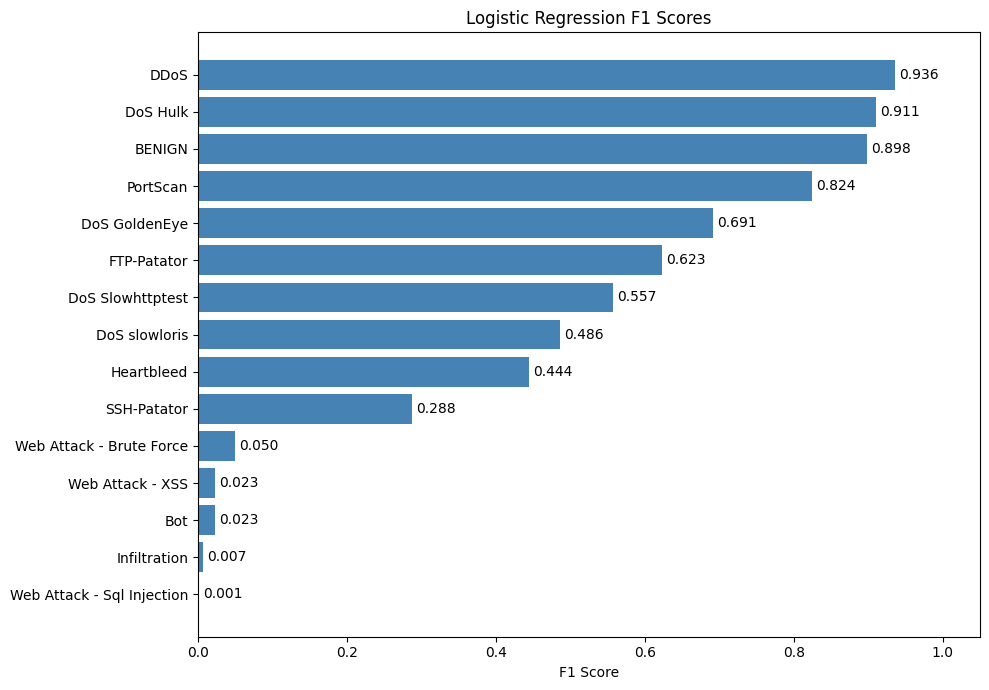

Saved results/logistic_f1_chart.png


In [34]:
# logistic regression evaluation
lr_result = evaluate_model_predictions("Logistic Regression", y_test, lr_predict(lr_artifacts, X_test))
save_classification_report(lr_result, RESULTS / "logistic_report.txt")

lr_report_dict = lr_result.classification_report_df.fillna(0).to_dict(orient="index")
(RESULTS / "logistic_report.json").write_text(json.dumps(lr_report_dict))

with open(RESULTS / "logistic_artifacts.pkl", "wb") as f:
    pickle.dump(lr_artifacts, f)

print(lr_result.classification_report_text)

save_f1_chart(
	lr_report_dict,
	title="Logistic Regression F1 Scores",
	save_path=str(RESULTS / "logistic_f1_chart.png")
)

In [35]:
# random forest training
from src.models.rf import train_rf_classifier, predict_labels as rf_predict

rf_artifacts = train_rf_classifier(
	X_resampled,
	y_resampled,
	random_state=42,
	n_estimators=200,
	max_depth=None,
)
print("Random forest training complete.")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 14 concurrent workers.
[Parallel(n_jobs=-1)]: Done  22 tasks      | elapsed:    7.9s
[Parallel(n_jobs=-1)]: Done 172 tasks      | elapsed:   46.7s


Random forest training complete.


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   53.6s finished


[Parallel(n_jobs=14)]: Using backend ThreadingBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done  22 tasks      | elapsed:    0.1s
[Parallel(n_jobs=14)]: Done 172 tasks      | elapsed:    0.4s
[Parallel(n_jobs=14)]: Done 200 out of 200 | elapsed:    0.5s finished


                            precision    recall  f1-score   support

                    BENIGN      1.000     0.998     0.999    419506
                      DDoS      0.999     1.000     0.999     25616
                  DoS Hulk      0.995     0.999     0.997     34587
             DoS GoldenEye      0.989     0.998     0.993      2059
          DoS Slowhttptest      0.975     0.994     0.984      1046
                  PortScan      0.989     0.998     0.994     18173
             DoS slowloris      0.977     0.986     0.982      1077
               FTP-Patator      1.000     0.999     1.000      1187
                       Bot      0.477     0.964     0.638       391
  Web Attack - Brute Force      0.743     0.687     0.714       294
               SSH-Patator      1.000     0.997     0.998       644
          Web Attack - XSS      0.350     0.534     0.423       131
              Infiltration      1.000     0.571     0.727         7
                Heartbleed      1.000     1.000

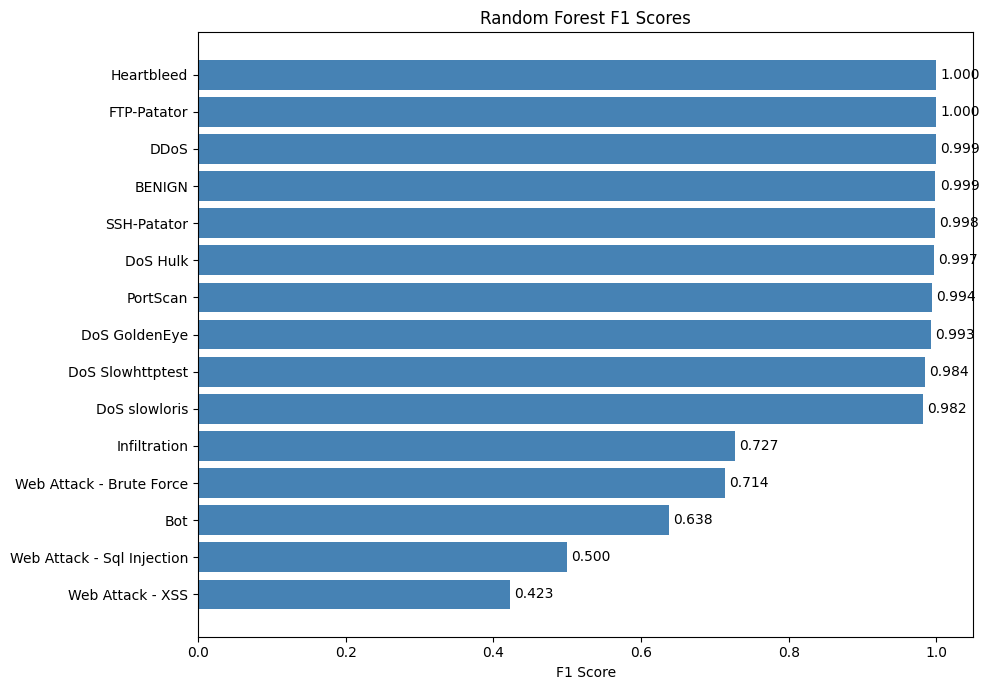

Saved results/rf_f1_chart.png


In [36]:
# rf evaluation

rf_result = evaluate_model_predictions("Random Forest", y_test, rf_predict(rf_artifacts, X_test))
save_classification_report(rf_result, RESULTS / "rf_report.txt")

rf_report_dict = rf_result.classification_report_df.fillna(0).to_dict(orient="index")
(RESULTS / "rf_report.json").write_text(json.dumps(rf_report_dict))

with open(RESULTS / "rf_artifacts.pkl", "wb") as f:
	pickle.dump(rf_artifacts, f)

print(rf_result.classification_report_text)

save_f1_chart(
	rf_report_dict,
	title="Random Forest F1 Scores",
	save_path=str(RESULTS / "rf_f1_chart.png")
)

In [37]:
# train lightgbm classifier
# Gradient boosted trees. Uses a 10% validation split from the fit set for early stopping (patience=50). Faster and more memory-efficient than RF at similar accuracy.

from src.models.lgbm import train_lightgbm_classifier, predict_labels as lgbm_predict

lgbm_artifacts = train_lightgbm_classifier(
	X_resampled,
	y_resampled,
	X_valid=X_val,
	y_valid=y_val,
	class_weight="balanced",
	n_estimators=500,
	early_stopping_rounds=50,
	learning_rate=0.05,
	num_leaves=63,
	random_state=42,
)
print("LightGBM training complete.")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031906 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12576
[LightGBM] [Info] Number of data points in the train set: 1633425, number of used features: 59
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.70805

                            precision    recall  f1-score   support

                    BENIGN      1.000     0.998     0.999    419506
                      DDoS      0.999     1.000     0.999     25616
                  DoS Hulk      0.998     0.999     0.999     34587
             DoS GoldenEye      0.987     0.998     0.993      2059
          DoS Slowhttptest      0.964     0.994     0.979      1046
                  PortScan      0.989     0.999     0.994     18173
             DoS slowloris      0.973     0.988     0.980      1077
               FTP-Patator      0.994     0.999     0.997      1187
                       Bot      0.423     0.990     0.593       391
  Web Attack - Brute Force      0.690     0.680     0.685       294
               SSH-Patator      0.992     0.997     0.995       644
          Web Attack - XSS      0.358     0.527     0.426       131
              Infiltration      0.583     1.000     0.737         7
                Heartbleed      1.000     1.000

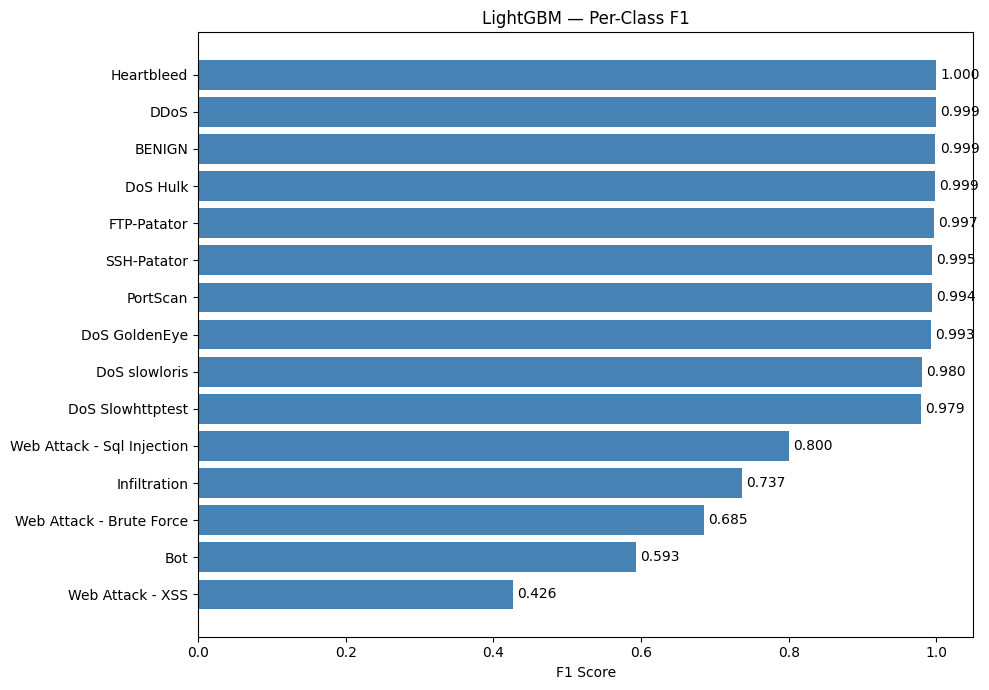

Saved results/lgbm_f1.png


In [38]:
# lightgbm evaluation
lgbm_result = evaluate_model_predictions("LightGBM", y_test, lgbm_predict(lgbm_artifacts, X_test))
save_classification_report(lgbm_result, RESULTS / "lgbm_report.txt")

lgbm_report_dict = lgbm_result.classification_report_df.fillna(0).to_dict(orient="index")
(RESULTS / "lgbm_report.json").write_text(json.dumps(lgbm_report_dict))

with open(RESULTS / "lgbm_artifacts.pkl", "wb") as f:
    pickle.dump(lgbm_artifacts, f)

print(lgbm_result.classification_report_text)

save_f1_chart(
    lgbm_report_dict,
    title="LightGBM — Per-Class F1",
    save_path=str(RESULTS / "lgbm_f1.png"),
)

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

def make_pca_views(X_train, X_val, X_test, n_components=0.95, random_state=42):
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test)
    
    pca = PCA(n_components=n_components, svd_solver="full", random_state=random_state)
    X_train_p = pca.fit_transform(X_train_s)
    X_val_p = pca.transform(X_val_s)
    X_test_p = pca.transform(X_test_s)
    
    cols = [f"PC{i+1}" for i in range(X_train_p.shape[1])]
    return (
        pd.DataFrame(X_train_p, index=X_train.index, columns=cols),
        pd.DataFrame(X_val_p, index=X_val.index, columns=cols),
        pd.DataFrame(X_test_p, index=X_test.index, columns=cols),
        pca
    )

X_fit_pca, X_val_pca, X_test_pca, pca_cnn = make_pca_views(
    X_fit, X_val, X_test, n_components=0.95, random_state=42
)
print("CNN PCA components:", pca_cnn.n_components_, "explained var:", pca_cnn.explained_variance_ratio_.sum())


CNN PCA components: 25 explained var: 0.9529515882417282


In [23]:
# mlp training
# Fully-connected neural network with BatchNorm and Dropout. `StandardScaler` and `LabelEncoder` are handled internally. Uses early stopping on validation loss (patience=5). Model saved as .keras file; scaler and encoder saved separately for Streamlit.

from src.models.mlp import train_mlp_classifier, predict_labels as mlp_predict

mlp_artifacts = train_mlp_classifier(
	X_fit_pca,
	y_fit,
	X_valid=X_val_pca,
	y_valid=y_val,
	epochs=30,
	batch_size=256,
	early_stopping_patience=10,
	_class_weight="balanced",
	learning_rate=1e-3,
	hidden_layer_sizes=(256, 128, 64),
	dropout_rate=0.3,
	random_state=42,
	verbose=1
)
print("MLP training complete.")



Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 25)             │            51 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,626 (197.76 KB)

 Trainable params: 49,679 (194.06 KB)

 Non-trainable params: 947 (3.70 KB)

None
Epoch 1/30
6208/6208 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.9620 - cross_entropy: 0.1230 - loss: 0.1230 - val_accuracy: 0.9755 - val_cross_entropy: 0.0604 - val_loss: 0.0604
Epoch 2/30
6208/6208 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.9752 - cross_entropy: 0.0609 - loss: 0.0609 - val_accuracy: 0.9790 - val_cross_entropy: 0.0494 - val_loss: 0.0494
Epoch 3/30
6208/6208 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.9768 - cross_entropy: 0.0551 - loss: 0.0551 - val_accuracy: 0.9805 - val_cross_entropy: 0.0446 - val_loss: 0.0446
Epoch 4/30
6208/6208 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.9777 - cross_entropy: 0.0521 - loss: 0.0521 - val_accuracy: 0.9807 - val_cross_entropy: 0.0444 - val_loss: 0.0444
Epoch 5/30
6208/6208 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.9782 - cross_entropy: 0.0504 - loss: 0.0504 - val_accuracy: 0.9810 - val_cross_entropy: 0.0415 - val_loss: 0.0415
Epoch 6/30
6208/6208 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9785 - cros

                            precision    recall  f1-score   support

                    BENIGN      0.990     0.988     0.989    419506
                      DDoS      0.999     0.986     0.993     25616
                  DoS Hulk      0.981     0.947     0.964     34587
             DoS GoldenEye      0.979     0.952     0.966      2059
          DoS Slowhttptest      0.883     0.971     0.925      1046
                  PortScan      0.805     0.946     0.870     18173
             DoS slowloris      0.955     0.960     0.957      1077
               FTP-Patator      0.991     0.981     0.986      1187
                       Bot      0.979     0.363     0.530       391
  Web Attack - Brute Force      0.818     0.061     0.114       294
               SSH-Patator      0.997     0.907     0.950       644
          Web Attack - XSS      0.000     0.000     0.000       131
              Infiltration      0.000     0.000     0.000         7
                Heartbleed      1.000     1.000

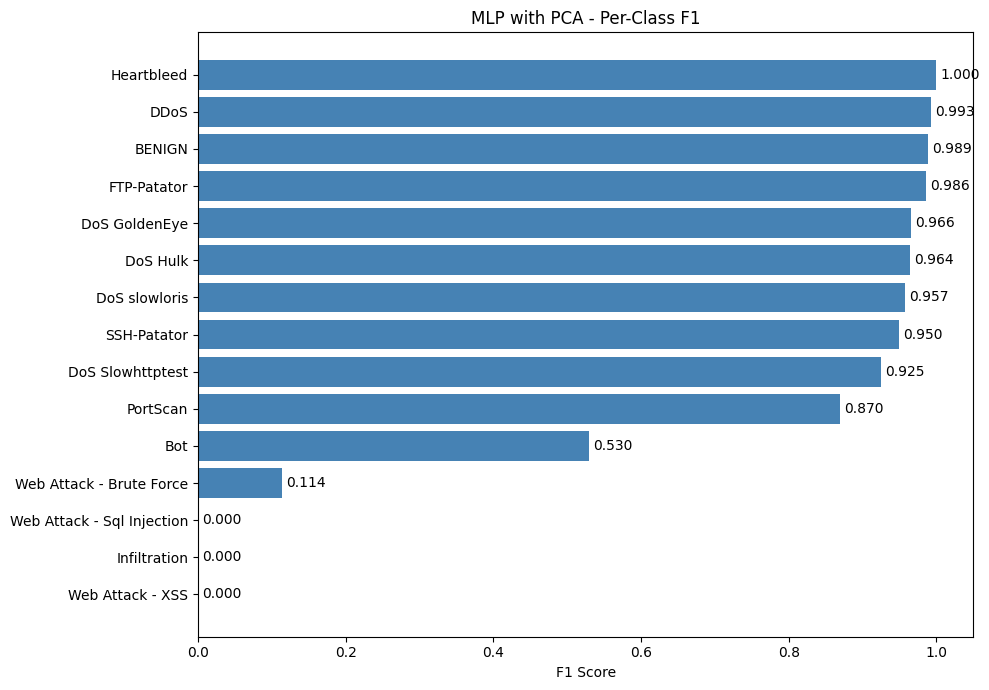

Saved results/mlp_pca_f1.png


In [25]:
# mlp evaluation
mlp_result = evaluate_model_predictions("MLP with PCA", y_test, mlp_predict(mlp_artifacts, X_test_pca))
save_classification_report(mlp_result, RESULTS / "mlp_pca_report.txt")

mlp_report_dict = mlp_result.classification_report_df.fillna(0).to_dict(orient="index")
(RESULTS / "mlp_pca_report.json").write_text(json.dumps(mlp_report_dict))

# save keras model seperately since it can't be pickled
mlp_artifacts.model.save(RESULTS / "mlp_model.keras")
with open(RESULTS / "mlp_pca_scaler.pkl", "wb") as f:
	pickle.dump(mlp_artifacts.scaler, f)
with open(RESULTS / "mlp_pca_encoder.pkl", "wb") as f:
	pickle.dump(mlp_artifacts.label_encoder, f)

print(mlp_result.classification_report_text)

save_f1_chart(
	mlp_report_dict,
	title="MLP with PCA - Per-Class F1",
	save_path=str(RESULTS / "mlp_pca_f1.png")
)

In [39]:
# mlp training
# Fully-connected neural network with BatchNorm and Dropout. `StandardScaler` and `LabelEncoder` are handled internally. Uses early stopping on validation loss (patience=5). Model saved as .keras file; scaler and encoder saved separately for Streamlit.

from src.models.mlp import train_mlp_classifier, predict_labels as mlp_predict

mlp_artifacts = train_mlp_classifier(
	X_resampled,
	y_resampled,
	X_valid=X_val,
	y_valid=y_val,
	epochs=30,
	batch_size=256,
	early_stopping_patience=10,
	_class_weight="balanced",
	learning_rate=1e-3,
	hidden_layer_sizes=(256, 128, 64),
	dropout_rate=0.3,
	random_state=42,
	verbose=1
)
print("MLP training complete.")



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_2 (Normalization) │ (None, 61)             │           123 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        15,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,914 (234.04 KB)

 Trainable params: 58,895 (230.06 KB)

 Non-trainable params: 1,019 (3.98 KB)

None
Epoch 1/30
6381/6381 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9101 - loss: 0.2018 - val_accuracy: 0.9226 - val_loss: 0.2355
Epoch 2/30
6381/6381 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9253 - loss: 0.1441 - val_accuracy: 0.9388 - val_loss: 0.1986
Epoch 3/30
6381/6381 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9287 - loss: 0.1364 - val_accuracy: 0.9429 - val_loss: 0.1797
Epoch 4/30
6381/6381 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9307 - loss: 0.1318 - val_accuracy: 0.9522 - val_loss: 0.1559
Epoch 5/30
6381/6381 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9333 - loss: 0.1283 - val_accuracy: 0.9521 - val_loss: 0.1613
Epoch 6/30
6381/6381 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9345 - loss: 0.1262 - val_accuracy: 0.9554 - val_loss: 0.1442
Epoch 7/30
6381/6381 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9353 - loss: 0.1242 - val_accuracy: 0.9546 - val_loss: 0.1513
Epoch 8/30
6381/6381 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9347 - lo

                            precision    recall  f1-score   support

                    BENIGN      1.000     0.952     0.975    419506
                      DDoS      0.956     0.999     0.977     25616
                  DoS Hulk      0.953     0.996     0.974     34587
             DoS GoldenEye      0.861     0.993     0.922      2059
          DoS Slowhttptest      0.775     0.989     0.869      1046
                  PortScan      0.738     0.999     0.849     18173
             DoS slowloris      0.836     0.990     0.906      1077
               FTP-Patator      0.913     0.993     0.952      1187
                       Bot      0.049     1.000     0.094       391
  Web Attack - Brute Force      0.231     0.180     0.203       294
               SSH-Patator      0.866     0.932     0.898       644
          Web Attack - XSS      0.063     0.962     0.118       131
              Infiltration      0.015     0.714     0.029         7
                Heartbleed      1.000     1.000

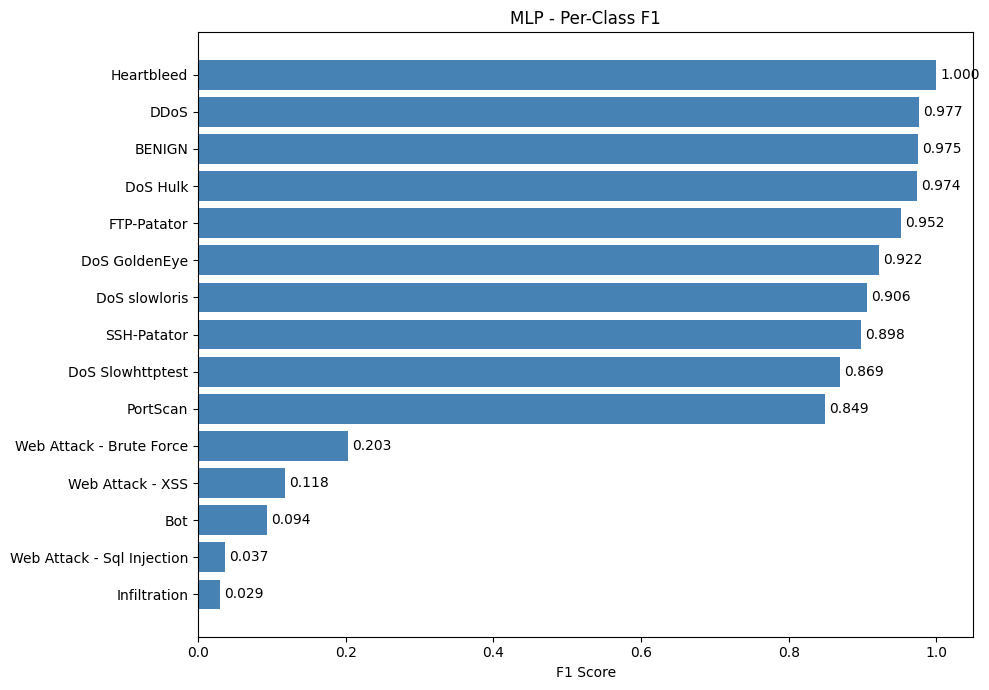

Saved results/mlp_f1.png


In [40]:
# mlp evaluation
mlp_result = evaluate_model_predictions("MLP", y_test, mlp_predict(mlp_artifacts, X_test))
save_classification_report(mlp_result, RESULTS / "mlp_report.txt")

mlp_report_dict = mlp_result.classification_report_df.fillna(0).to_dict(orient="index")
(RESULTS / "mlp_report.json").write_text(json.dumps(mlp_report_dict))

# save keras model seperately since it can't be pickled
mlp_artifacts.model.save(RESULTS / "mlp_model.keras")
with open(RESULTS / "mlp_scaler.pkl", "wb") as f:
	pickle.dump(mlp_artifacts.scaler, f)
with open(RESULTS / "mlp_encoder.pkl", "wb") as f:
	pickle.dump(mlp_artifacts.label_encoder, f)

print(mlp_result.classification_report_text)

save_f1_chart(
	mlp_report_dict,
	title="MLP - Per-Class F1",
	save_path=str(RESULTS / "mlp_f1.png")
)

In [22]:
# cnn training
# 1D convolutional neural network. Uses early stopping on validation loss (patience=10). Model saved as .keras file; scaler and encoder saved separately for Streamlit.

from src.models.cnn import train_cnn_classifier, predict_labels as cnn_predict


cnn_artifacts = train_cnn_classifier(
	X_fit_pca,
	y_fit,
	X_valid=X_val_pca,
	y_valid=y_val,
	epochs=30,
	batch_size=128,
	early_stopping_patience=10,
	learning_rate=1e-3,
	verbose=1,
    conv_filters=(64,32),
    dense_units=64,
    dropout_rate=0.0
)
print("CNN training complete.")

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_20 (Conv1D)              │ (None, 25, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_20 (MaxPooling1D) │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_21 (Conv1D)              │ (None, 12, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_21 (MaxPooling1D) │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,759 (77.18 KB)

 Trainable params: 19,759 (77.18 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/30
12415/12415 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step - accuracy: 0.9731 - cross entropy: 0.0752 - loss: 0.0791 - val_accuracy: 0.9797 - val_cross entropy: 0.0489 - val_loss: 0.0489
Epoch 2/30
12415/12415 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step - accuracy: 0.9793 - cross entropy: 0.0482 - loss: 0.0482 - val_accuracy: 0.9798 - val_cross entropy: 0.0457 - val_loss: 0.0457
Epoch 3/30
12415/12415 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step - accuracy: 0.9805 - cross entropy: 0.0444 - loss: 0.0444 - val_accuracy: 0.9807 - val_cross entropy: 0.0428 - val_loss: 0.0428
Epoch 4/30
 5264/12415 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.9813 - cross entropy: 0.0422 - loss: 0.0422

KeyboardInterrupt: 

                            precision    recall  f1-score   support

                    BENIGN      0.987     0.992     0.990    419506
                      DDoS      0.996     0.998     0.997     25616
                  DoS Hulk      0.995     0.922     0.957     34587
             DoS GoldenEye      0.968     0.959     0.963      2059
          DoS Slowhttptest      0.880     0.945     0.911      1046
                  PortScan      0.851     0.893     0.871     18173
             DoS slowloris      0.947     0.970     0.958      1077
               FTP-Patator      0.963     0.976     0.970      1187
                       Bot      0.979     0.355     0.522       391
  Web Attack - Brute Force      1.000     0.061     0.115       294
               SSH-Patator      0.997     0.905     0.949       644
          Web Attack - XSS      1.000     0.023     0.045       131
              Infiltration      0.000     0.000     0.000         7
                Heartbleed      1.000     1.000

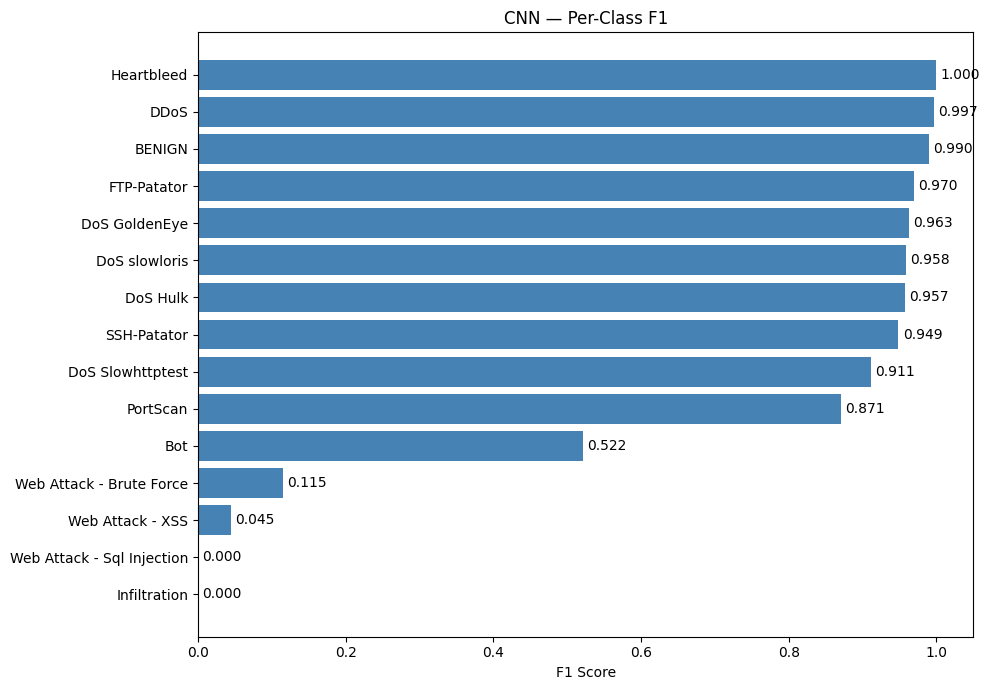

Saved results/cnn_f1.png


In [21]:


cnn_result = evaluate_model_predictions("CNN", y_test, cnn_predict(cnn_artifacts, X_test_pca))
save_classification_report(cnn_result, RESULTS / "cnn_report.txt")

cnn_report_dict = cnn_result.classification_report_df.fillna(0).to_dict(orient="index")
(RESULTS / "cnn_report.json").write_text(json.dumps(cnn_report_dict))

cnn_artifacts.model.save(RESULTS / "cnn_model.keras")
with open(RESULTS / "cnn_scaler.pkl", "wb") as f:
    pickle.dump(cnn_artifacts.scaler, f)
with open(RESULTS / "cnn_encoder.pkl", "wb") as f:
    pickle.dump(cnn_artifacts.label_encoder, f)

print(cnn_result.classification_report_text)

save_f1_chart(
    cnn_report_dict,
    title="CNN — Per-Class F1",
    save_path=str(RESULTS / "cnn_f1.png"),
)


### Model Comparisons